In [2]:
import requests
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

## Drug target dataset

In [ ]:
dtypes={
    'pair_id': 'int32',
    'pipeline_run_id': 'category',
    'extraction_date': 'string',
    'nct_id': 'category',
    'brief_title': 'string',
    'overall_status': 'category',
    'phase': 'category',
    'conditions': 'string',
    'mesh_terms_condition': 'string',
    'mesh_terms_intervention': 'string',
    'drug_name_raw': 'string',
    'drug_name_norm': 'category',
    'intervention_type': 'category',
    'intervention_description': 'string',
    'target_primary': 'category',
    'targets_raw': 'string',
    'target_source': 'category',
    'target_confidence': 'category',
    'target_evidence_text': 'string',
    'target_evidence_source': 'category',
    'reference_db_version': 'category',
    'brief_summary': 'string',
    'detailed_description': 'string',
    'nlp_candidate_text': 'string',
    'sponsor_lead': 'category',
    'sponsor_collaborators': 'string',
    'start_date': 'string',
    'completion_date': 'string',
    'enrollment_count': 'float32',
    'enrollment_type': 'category',
    'eligibility_criteria': 'string',
    'eligibility_parsed': 'bool',
    'validation_warnings': 'string',
    'is_duplicate': 'bool'}

output=pd.read_csv(
    "clinicaltrials_pipeline\output\drug_target_dataset_repo_filled.csv",
    low_memory=True,
    memory_map=True,
    dtype=dtypes)

for col in output.select_dtypes(include='object').columns:
    if output[col].nunique() / len(output) < 0.5:
        output[col]=output[col].astype('category')

In [ ]:
count=output[['target_primary', 'targets_raw', 'detailed_description']].isna().all(axis=1).sum()

print(count)

80532


In [62]:
output.loc[output['target_primary'].notna(), 'drug_name_norm'].nunique()

66506

In [63]:
print(f"Dataset size: {output.shape}\n")
output.info()

Dataset size: (432275, 34)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432275 entries, 0 to 432274
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   pair_id                  432275 non-null  int32         
 1   pipeline_run_id          432275 non-null  category      
 2   extraction_date          432275 non-null  string        
 3   nct_id                   432275 non-null  category      
 4   brief_title              432275 non-null  string        
 5   overall_status           432275 non-null  category      
 6   phase                    355423 non-null  category      
 7   conditions               432240 non-null  string        
 8   mesh_terms_condition     346038 non-null  string        
 9   mesh_terms_intervention  345354 non-null  string        
 10  drug_name_raw            432273 non-null  string        
 11  drug_name_norm           432275 non-null  category

## Column information

In [64]:
print("\nColumn Information:")
for i in range(1,len(output.columns.tolist())):
    print(f"{i}:{output.columns.tolist()[i]}")


Column Information:
1:pipeline_run_id
2:extraction_date
3:nct_id
4:brief_title
5:overall_status
6:phase
7:conditions
8:mesh_terms_condition
9:mesh_terms_intervention
10:drug_name_raw
11:drug_name_norm
12:intervention_type
13:target_primary
14:targets_raw
15:target_source
16:target_confidence
17:target_evidence_source
18:reference_db_version
19:brief_summary
20:detailed_description
21:sponsor_lead
22:sponsor_collaborators
23:start_date
24:completion_date
25:enrollment_count
26:enrollment_type
27:eligibility_criteria
28:eligibility_parsed
29:is_duplicate
30:drug_smiles
31:start_year
32:pmid
33:target_type


In [65]:
# output.head(3)

## **Dataset Sample rows**

In [ ]:
output['target_source'].value_counts()
display(output.drop(columns=['eligibility_criteria' ]).head()) #

In [67]:
display(
    output
    .dropna(subset=['target_primary', 'targets_raw'])
    .drop(columns=[
        'eligibility_criteria','brief_summary','detailed_description','pair_id','sponsor_lead',
        'sponsor_collaborators','pipeline_run_id','extraction_date','nct_id','start_date', 'pmid','start_year',
        'completion_date','target_evidence_source','reference_db_version','mesh_terms_condition',
        'mesh_terms_intervention','intervention_type','eligibility_parsed','is_duplicate', 'enrollment_count','enrollment_type', 'target_source', 'drug_name_norm'
    ])
    .head(15)
)

,brief_title,overall_status,phase,conditions,drug_name_raw,target_primary,targets_raw,target_confidence,drug_smiles,target_type
2,An Open Label Study To Assess The Safety And Tolerability Of BEMA® Buprenorphine NX In Opioid Dependent Subjects,COMPLETED,PHASE2,Opioid Dependence,BEMA Buprenorphine NX films,Suboxone tablets,Suboxone tablets,medium,NaN,gene
3,A Trial of Rosiglitazone for Ulcerative Colitis,COMPLETED,PHASE2,Ulcerative Colitis|Inflammatory Bowel Disease,Rosiglitazone,Peroxisome proliferator-activated receptor gamma agonist,Peroxisome proliferator-activated receptor gamma agonist,high,CN(CCOc1ccc(CC2SC(=O)NC2=O)cc1)c1ccccn1,target
4,"""Efficacy and Safety of Phlai Capsule Compared to Placebo as the Treatment in Allergic Rhinitis Patients""",COMPLETED,PHASE3,Allergic Rhinitis,Phlai,AST,AST,medium,NaN,gene
5,"A Study of the Effectiveness and Safety of Risperidone Versus Placebo as add-on Therapy to Mood Stabilizers, in the Treatment of Manic Episodes Associated With Bipolar Disorder.",COMPLETED,PHASE3,Bipolar Disorder|Manic Disorder,risperidone,Serotonin 2a (5-HT2a) receptor antagonist,Serotonin 2a (5-HT2a) receptor antagonist|Serotonin 2c (5-HT2c) receptor antagonist|Dopamine D2 receptor antagonist,high,Cc1nc2n(c(=O)c1CCN1CCC(c3noc4cc(F)ccc34)CC1)CCCC2,target
6,An Open Label Study to Measure Efficacy of Fesoterodine (Toviaz) Post Surgery for Benign Prostatic Hyperplasia,COMPLETED,PHASE4,Bladder Outlet Obstruction,Toviaz (Fesoterodine),AUA,AUA,medium,NaN,gene
7,Treatment for Advanced B-Cell Lymphoma,COMPLETED,PHASE2,Diffuse Large Cell Lymphoma|Burkitt's Lymphoma|High Grade B-cell Lymphoma,Rituximab,B-lymphocyte antigen CD20 binding agent,B-lymphocyte antigen CD20 binding agent,high,NaN,target
9,Molecular Effects of Short-Term Celecoxib Treatment on Head and Neck Squamous Cell Carcinoma,COMPLETED,NaN,SQUAMOUS CELL CARCINOMA,celecoxib,Cyclooxygenase-2 inhibitor,Cyclooxygenase-2 inhibitor,high,Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1,target
10,Study of Methylnaltrexone in Opioid-Induced Constipation Patients,UNKNOWN,PHASE3,Opioid-induced Constipation,Methylnaltrexone (MNTX),pure opioid antagonists naltrexo,pure opioid antagonists naltrexo,medium,NaN,antagonist
11,Efficacy and Safety of Subcutaneous Immunotherapy in Birch Pollen Allergic Patients,TERMINATED,PHASE2,Allergy,Subcutaneous immunotherapy - Recombinant birch pollen,Bet v1,Bet v1,medium,NaN,gene
13,A Study of FK199B to Compare Efficacy With Zolpidem by Polysomnography in Patients With Insomnia,COMPLETED,PHASE3,Sleep Initiation and Maintenance Disorders,Zolpidem,GABA A receptor alpha-1/beta-1/gamma-2 positive allosteric modulator,GABA A receptor alpha-1/beta-1/gamma-2 positive allosteric modulator,high,Cc1ccc(-c2nc3ccc(C)cn3c2CC(=O)N(C)C)cc1,target


## **Null value count in columns**

Null values appear because many drug/biological names cannot be matched to a ChEMBL entry (missing, too short, not in ChEMBL, or synonym lookup budget exhausted)

target_primary stores the first mechanism‑of‑action string, while target_raw concatenates all distinct mechanisms for that drug.

The synonym lookup budget is a fixed limit (300 look‑ups) that caps how many extra ChEMBL searches by drug synonym the pipeline will perform to avoid excessive API calls.

In [68]:
# import pandas as pd

# output.head(20).to_csv("output_head.csv", index=False)

In [69]:
null_counts=output.isna().sum()
summary=pd.DataFrame({
    "column_name": null_counts.index,
    "null_count": null_counts.values})

summary["total"]=len(output)
summary["non_null"]=summary["total"] - summary["null_count"]
summary["percent_null"]=(summary["null_count"] / summary["total"]) * 100

summary=summary[summary["null_count"] > 0] \
    .sort_values("percent_null",ascending=False) \
    .reset_index(drop=True)
summary

,column_name,null_count,total,non_null,percent_null
0,drug_smiles,310935,432275,121340,71.929906
1,sponsor_collaborators,293238,432275,139037,67.835984
2,reference_db_version,274826,432275,157449,63.576658
3,target_evidence_source,274826,432275,157449,63.576658
4,pmid,270503,432275,161772,62.576601
5,start_year,248113,432275,184162,57.397027
6,start_date,248113,432275,184162,57.397027
7,completion_date,244982,432275,187293,56.672720
8,target_type,183914,432275,248361,42.545602
9,targets_raw,183914,432275,248361,42.545602


In [70]:
vc = output.loc[output['target_primary'].isna(), 'drug_name_norm'].value_counts().head(100).reset_index()
vc.columns = ['drug_name_norm', 'count']

fig = px.bar(vc, x='drug_name_norm', y='count', title='Top 100 drug_name_norm (target_primary is NULL)')
fig.update_layout(title_x=0.5, xaxis_title='Drug', yaxis_title='Count',xaxis_tickangle=45)
fig.show()

In [71]:
output[(output['intervention_type']!='DRUG') & (output['target_primary'].isna())].shape[0]

44147

In [72]:
(output['drug_name_norm']=='paracetamol').sum()

268

In [73]:
output[(output['intervention_type']=='COMBINATION_PRODUCT') & (output['target_primary'].isna())].shape[0]

2879

In [74]:
output.loc[output['drug_name_norm'].eq('paracetamol')].drop(columns=['eligibility_criteria','brief_summary','detailed_description',
                                                            'pair_id','sponsor_lead','sponsor_collaborators','pipeline_run_id',
                                                            'extraction_date','nct_id','start_date','completion_date','target_evidence_source',
                                                            'reference_db_version','mesh_terms_condition','mesh_terms_intervention','intervention_type',
                                                            'eligibility_parsed','is_duplicate','enrollment_count','enrollment_type','target_source',
                                                            'drug_name_norm','pmid','start_year']).head(10)

,brief_title,overall_status,phase,conditions,drug_name_raw,target_primary,targets_raw,target_confidence,drug_smiles,target_type
674,Effects of a Common Cold Treatment on Cognitive Function,COMPLETED,PHASE4,Common Cold,Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
5334,Preemptive Analgesia With Intravenous Paracetamol for Post-cesarean Section Pain Control,COMPLETED,PHASE4,Cesarean Section; Dehiscence,paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
8519,Strategy to Cope Pain and Discomfort in Mammography,UNKNOWN,NaN,Anxiety|Pain|Discomfort,Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
9605,Platelet Transfusion for Treatment of Patent Ductus Arteriosus in Thrombocytopenic Preterm Neonates,COMPLETED,PHASE3,Patent Ductus Arteriosus,Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
10066,Comparison Between Two Analgesic Methods for Pain Relief Following Surgical Abortion,UNKNOWN,NaN,Pain,Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
10617,Comparison of the Efficacy of Intravenous Dexketoprofen and Paracetamol in the Treatment of Sore Throat,COMPLETED,PHASE4,Sore Throat,paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
13222,Paracetamol Hypothermia Children,COMPLETED,PHASE4,Safety Issues,Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
13571,Adding Paracetamol to Ibuprofen for Treatment of Patent Ductus Arteriosus in Preterm Infants,COMPLETED,PHASE3,"Ductus Arteriosus, Patent",Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
16633,Paracetamol Versus Placebo in Conjunction With Strong Opioids for Cancer Pain,TERMINATED,NaN,Pain,Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme
18686,Evaluation of the Efficacy and Safety of Two Ibuprofen Combination Products for the Treatment of the Common Cold and Flu in Latin America,WITHDRAWN,PHASE3,Common Cold,Paracetamol,Central COX enzyme,Central COX enzyme,none,NaN,enzyme


In [75]:
# output.loc[output['target_primary'].eq('PK')].drop(columns=['eligibility_criteria','brief_summary','detailed_description',
#                                                             'pair_id','sponsor_lead','sponsor_collaborators','pipeline_run_id',
#                                                             'extraction_date','nct_id','start_date','completion_date','target_evidence_source',
#                                                             'reference_db_version','mesh_terms_condition','mesh_terms_intervention','intervention_type',
#                                                             'eligibility_parsed','is_duplicate','enrollment_count','enrollment_type','target_source',
#                                                             'drug_name_norm','pmid','start_year']).head(10)

## Unique values count in columns

In [76]:
nunique_vals=output.nunique()
summary3=nunique_vals.reset_index()
summary3.columns=["column","unique_count"]
summary3= summary3.sort_values(by="unique_count",ascending=False)
print(summary3)

                     column  unique_count
0                   pair_id        432275
3                    nct_id        249060
4               brief_title        248091
19            brief_summary        247259
27     eligibility_criteria        246459
10            drug_name_raw        189381
11           drug_name_norm        166443
20     detailed_description        154535
7                conditions         93200
32                     pmid         86059
9   mesh_terms_intervention         71227
8      mesh_terms_condition         44594
22    sponsor_collaborators         31238
14              targets_raw         29700
13           target_primary         29361
21             sponsor_lead         26423
25         enrollment_count          4581
30              drug_smiles          2623
24          completion_date           595
23               start_date           562
31               start_year            67
5            overall_status            13
33              target_type       

In [77]:
output['drug_name_raw'].nunique()

189381

In [78]:
# print(output.memory_usage(deep=True).sum() / (1024**2),"MB")

<Axes: xlabel='start_year'>

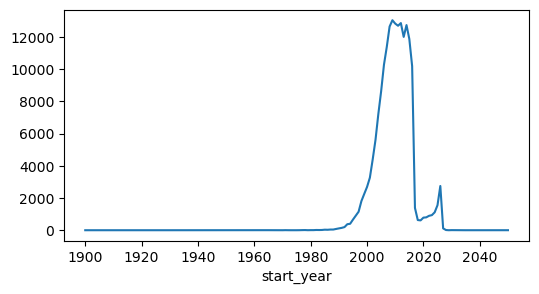

In [79]:
output['start_date']=pd.to_datetime(output['start_date'],errors='coerce')
output['completion_date']=pd.to_datetime(output['completion_date'],errors='coerce')
output['start_year']=output['start_date'].dt.year
output['start_year'].value_counts().sort_index().plot(kind='line',figsize=(6,3))

## Top 20 **Target** type

In [80]:
output['target_primary'].value_counts().head(20)

target_primary
DNA inhibitor                                                          13659
PK                                                                      6483
Tubulin inhibitor                                                       5918
Glucocorticoid receptor agonist                                         5596
Programmed cell death protein 1 inhibitor                               4052
Thymidylate synthase inhibitor                                          2837
Cyclooxygenase inhibitor                                                2513
Epidermal growth factor receptor erbB1 inhibitor                        2493
Mu opioid receptor agonist                                              2452
Vascular endothelial growth factor A inhibitor                          2289
B-lymphocyte antigen CD20 binding agent                                 2252
Ribonucleoside-diphosphate reductase RR1 inhibitor                      2231
GABA-A receptor; anion channel positive allosteric modulator 

In [81]:
output['targets_raw'].value_counts().head(20)

targets_raw
DNA inhibitor                                                                                                        12710
PK                                                                                                                    6483
Glucocorticoid receptor agonist                                                                                       5588
Tubulin inhibitor                                                                                                     4134
Programmed cell death protein 1 inhibitor                                                                             3984
Mu opioid receptor agonist                                                                                            2251
GABA-A receptor; anion channel positive allosteric modulator                                                          2206
B-lymphocyte antigen CD20 binding agent                                                                               2115
Sodi

## Phase distribution

In [82]:
output['phase'].value_counts()

phase
PHASE2          135140
PHASE3           81388
PHASE1           79272
PHASE4           51969
EARLY_PHASE1      7654
Name: count, dtype: int64

# **Visualizations**

## **Pie chart** (Top 15 values)

In [83]:
def pie_chart(df,col,top_n=15):
    vc=df[col].value_counts().head(top_n).reset_index()
    vc.columns=[col,'count']
    fig=px.pie(vc,names=col,values='count',title=f"{col} Distribution")
    fig.update_traces(
        textinfo='percent',
        hovertemplate=f"{col}: %{{label}}<br>Count: %{{value}}<br>Percentage: %{{percent}}<extra></extra>")
    fig.update_layout(
        title_x=0.5,
        height=500)
    fig.show()

## **Overall status of Drugs**

In [84]:
pie_chart(output,'overall_status')

## **Phase Distribution of Drugs**

In [85]:
pie_chart(output,'phase')

## **Intervention type of Drugs**

In [86]:
pie_chart(output,'intervention_type')

In [87]:
pie_chart(
    df=output[output['target_primary'].isna()],
    col='intervention_type'
)

## **Target source distribution**
**Sources:**

* **text_extraction_dictionary:** target filled via the Aho-Corasick gazetteer match against known vocabulary.
* **text_extraction_ner:** target filled via the NER model's entity extraction.
* **unresolved:** no target could be assigned by any method; field left null/tagged as such.

In [88]:
pie_chart(output,'target_source')

## **Target Condidence distribution**

In [89]:
pie_chart(output,'target_confidence')

## **Target Type distribution**

In [90]:
pie_chart(output,'target_type')

## **Bar chart** (Top 50 values)

In [91]:
print(output['target_primary'].value_counts(dropna=False).head(100))

target_primary
NaN                                                                    183914
DNA inhibitor                                                           13659
PK                                                                       6483
Tubulin inhibitor                                                        5918
Glucocorticoid receptor agonist                                          5596
Programmed cell death protein 1 inhibitor                                4052
Thymidylate synthase inhibitor                                           2837
Cyclooxygenase inhibitor                                                 2513
Epidermal growth factor receptor erbB1 inhibitor                         2493
Mu opioid receptor agonist                                               2452
Vascular endothelial growth factor A inhibitor                           2289
B-lymphocyte antigen CD20 binding agent                                  2252
Ribonucleoside-diphosphate reductase RR1 inhibito

In [92]:
# print(output['targets_raw'].value_counts(dropna=False).head(500))

## **Top 50 Targets (Primary) by Drug Count**

In [94]:
vc=(
    output[output['target_primary'] != 'Unknown']
    .groupby('target_primary')['drug_name_norm']
    .count()  # .count() if duplicates should be counted
    .sort_values(ascending=False)
    .head(50)
    .reset_index(name='drug_count'))
fig=px.bar(
    vc,
    x='target_primary',
    y='drug_count',
    title='Top 50 Targets (Primary) by Drug Count',
    height=600,
    width=1200)
fig.update_layout(xaxis_tickangle=45)
fig.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10860\1533238691.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  output[output['target_primary'] != 'Unknown']


## **Top 50 Targets (Raw) by Drug Count**

In [95]:
vc=(
    output.groupby('targets_raw')['drug_name_norm']
      .count()
      .sort_values(ascending=False)
      .head(50)
      .reset_index(name='drug_count'))
fig=px.bar(vc,x='targets_raw',y='drug_count',
             title='Top 50 Targets (Raw) by Drug Count', height=600, width=1200)
fig.update_layout(xaxis_tickangle=45)
fig.show()

In [96]:
def bar_chart(df,col,top_n=50):
    vc=df[col].value_counts().head(top_n).reset_index()
    vc.columns=[col,'count']
    total=vc['count'].sum()
    vc['percent']=(vc['count'] / total) * 100
    fig=px.bar(vc,x=col,y='count',text='count',title=f"{col} Distribution (Top 50)")
    fig.update_traces(
        textposition='outside',
        hovertemplate=(
            f"{col}: %{{x}}<br>"
            "Count: %{y}<br>"
            "Percentage: %{customdata[0]:.2f}%<extra></extra>"),
        customdata=vc[['percent']].values)
    fig.update_layout(xaxis_tickangle=-45,title_x=0.5,height=550)
    fig.show()

## **Conditions distribution**

In [97]:
bar_chart(output,'conditions')

## **Drug name normalized**

In [98]:
bar_chart(output,'drug_name_norm')

## **Sponsor lead**

In [99]:
bar_chart(output,'sponsor_lead')

## **Enrolment type**

In [100]:
bar_chart(output,'enrollment_type')

## **Time trend visualizations**

In [101]:
def time_trend(df,col):
    temp=df.copy()
    temp[col]=pd.to_datetime(temp[col],errors='coerce')
    vc=temp[col].dt.year.value_counts().sort_index()

    fig=px.line(x=vc.index,y=vc.values,title=f"{col} Trend Over Years")
    fig.update_traces(
        hovertemplate="Year: %{x}<br>Count: %{y}<extra></extra>"
    )
    fig.update_layout(title_x=0.5)
    fig.show()

In [102]:
time_trend(output,'start_date')
time_trend(output,'completion_date')

In [103]:
top_target=(
    output.groupby('target_primary')['drug_name_norm']
      .nunique()
      .idxmax())

top_count=(
    output.groupby('target_primary')['drug_name_norm']
      .nunique()
      .max())

print(top_target)

PK


C:\Users\Admin\AppData\Local\Temp\ipykernel_10860\2580569213.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  output.groupby('target_primary')['drug_name_norm']
C:\Users\Admin\AppData\Local\Temp\ipykernel_10860\2580569213.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  output.groupby('target_primary')['drug_name_norm']


## **Review File**

In [104]:
review=pd.read_csv(r"D:\ChEMBL\clinicaltrials_pipeline\output\review_queue.csv")

In [105]:
review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309230 entries, 0 to 309229
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   pair_id                  309230 non-null  int64 
 1   nct_id                   309230 non-null  object
 2   drug_name_raw            309228 non-null  object
 3   drug_name_norm           309230 non-null  object
 4   mesh_terms_intervention  214114 non-null  object
dtypes: int64(1), object(4)
memory usage: 11.8+ MB


In [106]:
review.head()

,pair_id,nct_id,drug_name_raw,drug_name_norm,mesh_terms_intervention
0,0,NCT02520219,GDP,gdp,Guanosine Diphosphate|endostar protein
1,1,NCT02520219,Endostar,endostar,Guanosine Diphosphate|endostar protein
2,2,NCT01666119,BEMA Buprenorphine NX films,bema buprenorphine nx films,NaN
3,4,NCT00065065,Placebo,placebo,Rosiglitazone
4,5,NCT04182919,Phlai,phlai,NaN


In [107]:
summary2=pd.DataFrame({
    "total": len(review),
    "null_count": review.isnull().sum()})
summary2["non_null"]=summary2["total"]-summary2["null_count"]
summary2["percent_null"]=(summary2["null_count"]/summary2["total"])*100
summary2=summary2[summary2["null_count"]>0]
summary2=summary2.sort_values("percent_null",ascending=False)

summary2=summary2.reset_index()
summary2=summary2.rename(columns={'index': 'column_name'})
summary2

,column_name,total,null_count,non_null,percent_null
0,mesh_terms_intervention,309230,95116,214114,30.758982
1,drug_name_raw,309230,2,309228,0.000647


In [108]:
import plotly.express as px

fig=px.bar(
    summary2,
    x='column_name',
    y='percent_null',
    title='Percentage of Null Values per Column',
    labels={
        'column_name': 'Column Name',
        'percent_null': 'Null Percentage (%)'},
    text='percent_null')

fig.update_traces(texttemplate='%{text:.2f}%',textposition='outside')

fig.update_layout(
    xaxis_tickangle=-45,
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    margin=dict(b=100))
fig.show()

* **`main.py`:** 
    - **Entry point.** 
    - Orchestrates the full pipeline
    - spins up worker processes,wires async queues between stages,and calls each module in order from 
    - fetch → parse → normalize → resolve → build → report.

* **`config.py`** 
    - **Central config store.**
    - Holds every constant the pipeline uses: 
    - API URL,file paths,regex patterns,field lists,enums,and thresholds. No logic,just values.

* **`m1_fetch.py`**
    - **Data fetcher.** 
    - Hits the ClinicalTrials.gov v2 API page by page
    - Handles rate limiting via a token bucket,retries on failure,caches responses,and checkpoints progress so interrupted runs can resume.

* **`m2_parse.py`**
    - **Raw JSON parser.** 
    - Unpacks each API response,extracts relevant fields from nested study objects.
    - Filters to drug/biological interventions only,and emits flat row-per-intervention DataFrames in chunks.

* **`m3_normalize.py`**
    - **Drug name cleaner.**
    - Strips dosages,routes,salt suffixes,and extra whitespace from raw drug names
    - Maps brand names to generics,and flags intra-chunk duplicates.

* **`m4_resolve.py`**
    - **Target resolver.** 
    - Maps normalized drug names to biological targets using three cascading strategies:
    - Exact lookup against DrugBank/ChEMBL,MeSH term matching,then NLP pattern extraction from trial text. Assigns confidence level to each result.

* **`m5_build.py`**
    - **Output writer.**
    - Receives resolved records,deduplicates across chunks,validates status values
    - Routes rows to the main CSV,a review queue for unresolved targets,and a duplicates log.

* **`m6_report.py`**
    - **Quality reporter.** 
    - Computes null rates,duplicate rates,coverage vs expected API count.
    - Runs live spot-checks against the API per condition. Writes a JSON run report and returns an exit code reflecting pass/fail.

* **`state.py`**
    - **State manager.**
    - Reads and writes checkpoint files for API pagination progress and pair ID allocation so the pipeline is safely resumable and pair IDs are globally unique across runs.

* **`utils.py`**
    - **File utilities.**
    - Provides atomic read/write for JSON and gzip files using temp-file-then-rename to prevent corruption on crash.

* **`requirements.txt`** 
    - **Dependency manifest.**
    - Pins `aiohttp`,`aiofiles`,`pandas`,`numpy`,and `requests` to exact versions.

* **`pipeline.log`**
    - **Runtime log.**
    - Records timestamped INFO/WARNING/ERROR events from each pipeline run,used for diagnosing failures like stale page tokens or zero-row outputs.

| **S.no** | **Column**                   | **What it contains**                                                                          |
| -------- | ---------------------------- | --------------------------------------------------------------------------------------------- |
| 1        | **pair_id**                  | Unique integer ID for each drug–trial pair in this pipeline run                               |
| 2        | **pipeline_run_id**          | UUID identifying which specific pipeline execution produced this row                          |
| 3        | **extraction_date**          | Date this row was written to the CSV                                                          |
| 4        | **nct_id**                   | The official ClinicalTrials.gov trial identifier (e.g. NCT01234567)                           |
| 5        | **brief_title**              | Short human-readable title of the clinical trial                                              |
| 6        | **overall_status**           | Current trial status: RECRUITING,COMPLETED,TERMINATED,etc.                                 |
| 7        | **phase**                    | Highest clinical trial phase: PHASE1 through PHASE4,or NA                                    |
| 8        | **conditions**               | Disease(s) or condition(s) the trial is studying,pipe-separated                              |
| 9        | **mesh_terms_condition**     | Standardized MeSH vocabulary terms for the condition(s),pipe-separated                       |
| 10       | **mesh_terms_intervention**  | Standardized MeSH vocabulary terms for the intervention(s),pipe-separated                    |
| 11       | **drug_name_raw**            | Intervention name exactly as the sponsor entered it on ClinicalTrials.gov                     |
| 12       | **drug_name_norm**           | Cleaned drug name after stripping salts,dosages,and routes                                  |
| 13       | **intervention_type**        | Category of the intervention: DRUG,BIOLOGICAL,COMBINATION_PRODUCT,or DIETARY_SUPPLEMENT    |
| 14       | **intervention_description** | Free-text description of the intervention as entered by the sponsor (mostly empty)            |
| 15       | **target_primary**           | Single best biological target assigned to the drug                                            |
| 16       | **targets_raw**              | All targets found before selecting the primary,pipe-separated                                |
| 17       | **target_source**            | Which tier resolved the target: drugbank,chembl,mesh,nlp,or none                          |
| 18       | **target_confidence**        | Confidence level of the target assignment: high,medium,low,or none                         |
| 19       | **target_evidence_text**     | The specific text fragment that triggered the target assignment                               |
| 20       | **target_evidence_source**   | Where the evidence text came from: brief_summary,detailed_description,or nlp_candidate_text |
| 21       | **reference_db_version**     | Version tag of the DrugBank or ChEMBL database entry used,if applicable                      |
| 22       | **brief_summary**            | Short paragraph describing the trial's purpose,as written by the sponsor                     |
| 23       | **detailed_description**     | Full-length trial description text,as written by the sponsor                                 |
| 24       | **nlp_candidate_text**       | Sentences extracted from the description that contained target-relevant keywords              |
| 25       | **sponsor_lead**             | Name of the primary organization running the trial                                            |
| 26       | **sponsor_collaborators**    | Names of collaborating organizations,pipe-separated                                          |
| 27       | **start_date**               | Date the trial began or is expected to begin                                                  |
| 28       | **completion_date**          | Expected or actual primary completion date                                                    |
| 29       | **enrollment_count**         | Number of participants enrolled or targeted for enrollment                                    |
| 30       | **enrollment_type**          | Whether enrollment count is ACTUAL (real) or ANTICIPATED (planned)                            |
| 31       | **eligibility_criteria**     | Full inclusion and exclusion criteria text for trial participants                             |
| 32       | **eligibility_parsed**       | Boolean flag; currently always False as eligibility parsing is not yet implemented            |
| 33       | **validation_warnings**      | Pipe-separated flags for any data quality issues detected in this row                         |
| 34       | **is_duplicate**             | True if this drug–trial pair appeared more than once; duplicates are logged separately        |
